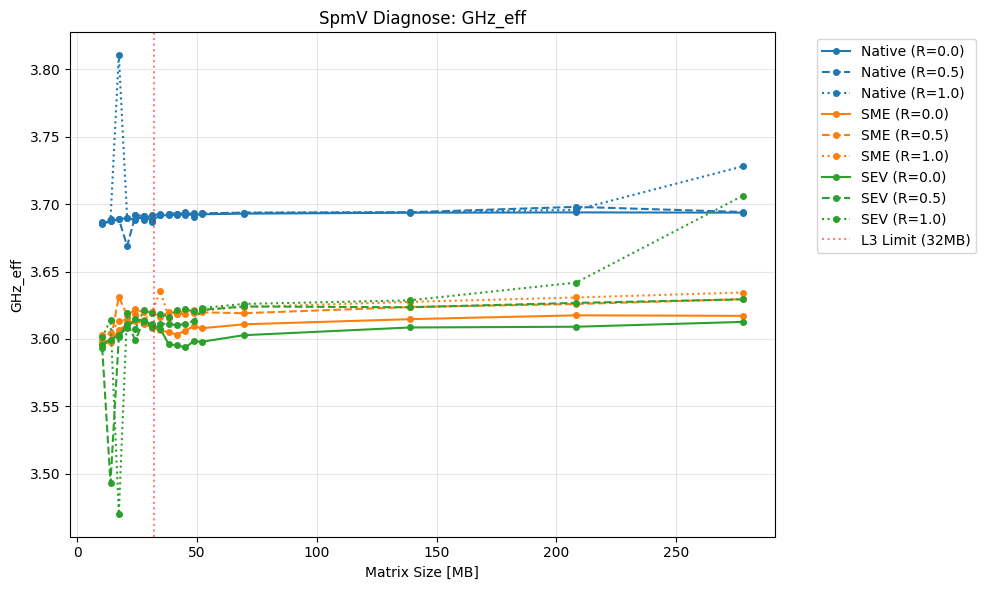

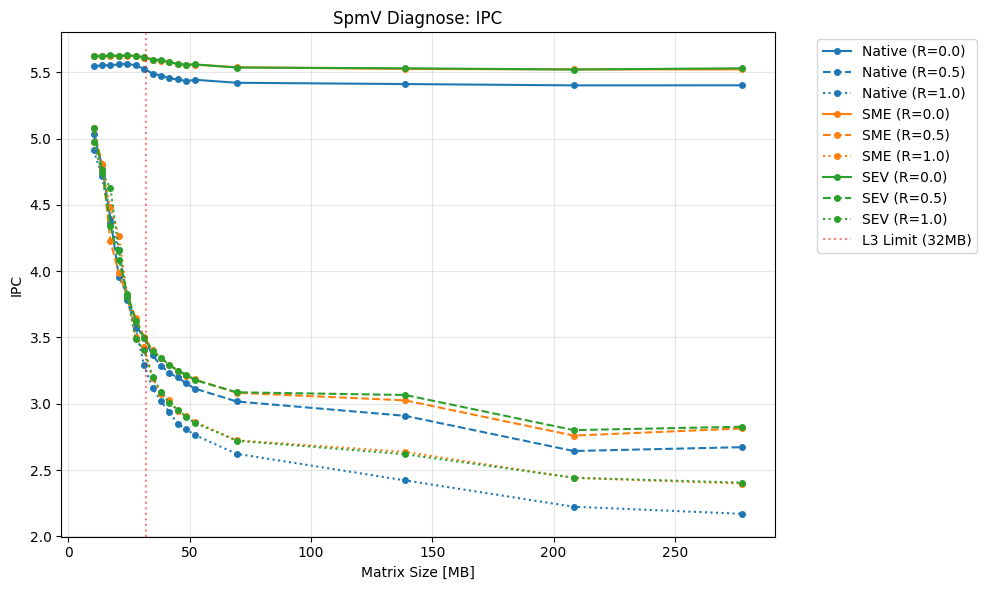

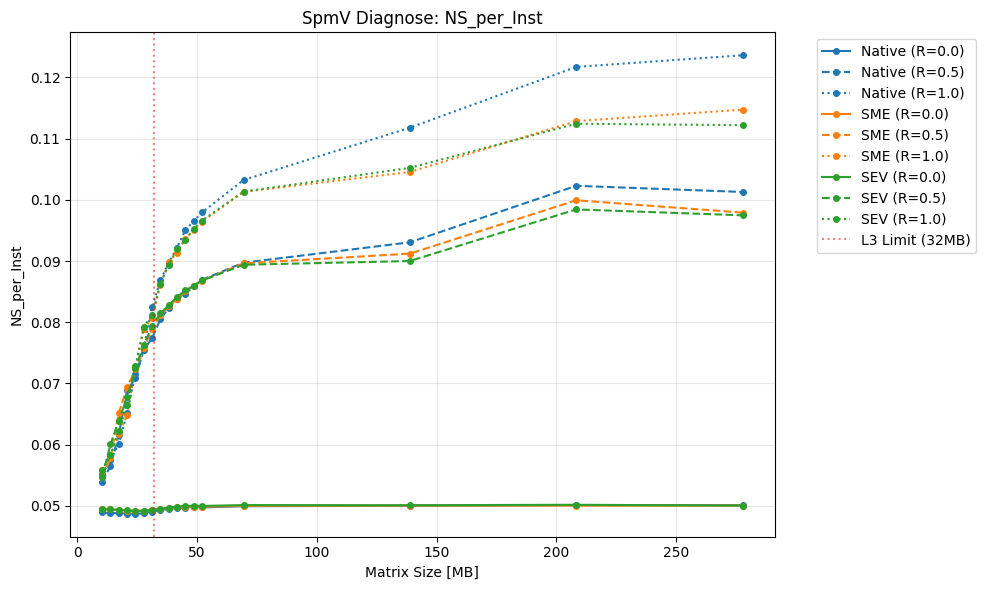

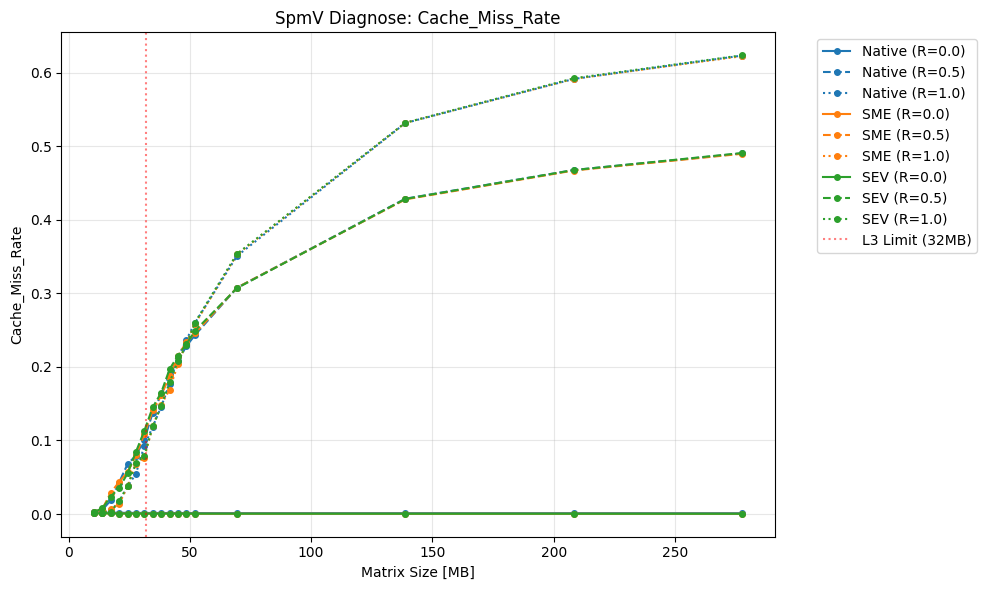

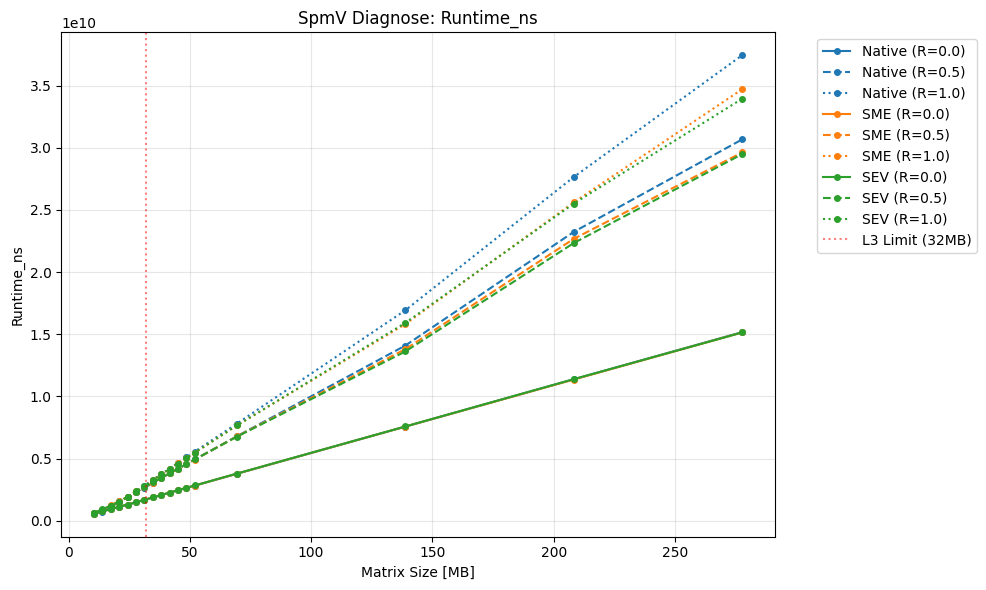

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
matrix_base_dir = "./matrices"
csvs = {
    "Native": "/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260202_203250/summary.csv",
    "SME": "/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260202_202818/summary.csv",
    "SEV": "/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260202_205913/summary.csv",
}

type_colors = {"Native": "tab:blue", "SME": "tab:orange", "SEV": "tab:green"}
randomness_styles = {0.0: "-", 0.5: "--", 1.0: ":"}

perf_cols = ["Instructions", "Cycles", "Cache_Misses", "Cache_Refs", "L1_Loads"]
runtime_col = "Runtime_ns"
metrics = [runtime_col] + perf_cols

# --- Helpers ---
def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_base_dir, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

# --- Load ---
dfs = [pd.read_csv(p).assign(Type=l) for l, p in csvs.items() if os.path.exists(p)]
df_all = pd.concat(dfs, ignore_index=True)

# --- Aggregate ---
df_med = df_all.groupby(["Type", "N", "Randomness"])[metrics].min().reset_index()

# --- DIAGNOSE-METRIKEN BERECHNEN ---
df_med["MB"] = df_med.apply(get_mb, axis=1)

# 1. Effektive Frequenz (GHz) -> Zeigt Turbo-Unterschiede
df_med["GHz_eff"] = df_med["Cycles"] / df_med["Runtime_ns"]

# 2. IPC -> Zeigt Effizienz der Pipeline
df_med["IPC"] = df_med["Instructions"] / df_med["Cycles"]

# 3. Zeit pro Instruktion (ns) -> Absolute Performance-Metrik
df_med["NS_per_Inst"] = df_med["Runtime_ns"] / df_med["Instructions"]

# 4. Cache Miss Rate
df_med["Cache_Miss_Rate"] = df_med["Cache_Misses"] / df_med["Cache_Refs"]

df_med = df_med.dropna(subset=["MB"]).sort_values("MB")

# Liste der Plots (Diagnose-Metriken zuerst, um das Rätsel zu lösen)
plot_list = ["GHz_eff", "IPC", "NS_per_Inst", "Cache_Miss_Rate", "Runtime_ns"]

# --- Plotting ---
def plot_metric(m):
    plt.figure(figsize=(10, 6))
    for t, color in type_colors.items():
        subset_type = df_med[df_med["Type"] == t]
        for r, style in randomness_styles.items():
            d = subset_type[subset_type["Randomness"] == r]
            if not d.empty:
                plt.plot(d["MB"], d[m], linestyle=style, color=color, marker="o", markersize=4, label=f"{t} (R={r})")

    plt.axvline(x=32, color='red', linestyle=':', alpha=0.5, label='L3 Limit (32MB)')
    plt.xlabel("Matrix Size [MB]")
    plt.ylabel(m)
    plt.title(f"SpmV Diagnose: {m}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for m in plot_list:
    plot_metric(m)